In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Fleet Fuel Efficiency Analysis
## Project Objective
#This project analyzes fleet fuel consumption and evaluates truck performance based on a benchmark of 1.8 km/L.
## Key Metric
#Fuel efficiency is calculated as:
#Fuel Efficiency = Distance / Fuel
## Benchmark
#- ≥ 1.8 km/L → Excellent
#- < 1.8 km/L → Needs Improvement
## Key Insights
#The fleet average fuel efficiency is 1.65 km/L, which is below the target benchmark of 1.8 km/L.
#Approximately 35% of trucks are operating below the expected performance level.
#Some trucks consistently show poor fuel efficiency, indicating potential maintenance or driver behavior issues.

/kaggle/input/datasets/riderxox/fuel-log/Fuel Log.csv


In [2]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/riderxox/fuel-log/Fuel Log.csv')
df.head()

,NO,TRUCK ID,DRIVER NAME,DATE,PERVIOUS ODO,CURRENT ODO,DISTANANCE,LITERS,K/L,TARGET CONS
0,1,TID-1,NAME1,1/1/2026,1000,2000,1000,900,1.111111,1.8
1,2,TID-2,NAME2,1/1/2026,1200,1890,690,800,0.862500,1.8
2,3,TID-3,NAME3,1/1/2026,800,2000,1200,700,1.714286,1.8
3,4,TID-4,NAME4,1/1/2026,1300,2500,1200,900,1.333333,1.8
4,5,TID-5,NAME5,1/1/2026,1300,2500,1200,444,2.702703,1.8


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   NO            99 non-null     int64  
 1   TRUCK ID      99 non-null     object 
 2   DRIVER NAME   99 non-null     object 
 3   DATE          99 non-null     object 
 4   PERVIOUS ODO  99 non-null     int64  
 5   CURRENT ODO   99 non-null     int64  
 6   DISTANANCE    99 non-null     int64  
 7   LITERS        99 non-null     int64  
 8   K/L           99 non-null     float64
 9   TARGET CONS   99 non-null     float64
dtypes: float64(2), int64(5), object(3)
memory usage: 7.9+ KB


,NO,PERVIOUS ODO,CURRENT ODO,DISTANANCE,LITERS,K/L,TARGET CONS
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,9.900000e+01
mean,50.000000,1290.909091,2483.737374,1192.828283,375.222222,3.341513,1.800000e+00
std,28.722813,59.058790,92.907523,54.866078,116.533919,0.537914,1.562222e-15
min,1.000000,800.000000,1890.000000,690.000000,309.000000,0.862500,1.800000e+00
25%,25.500000,1300.000000,2500.000000,1200.000000,344.000000,3.488372,1.800000e+00
50%,50.000000,1300.000000,2500.000000,1200.000000,344.000000,3.488372,1.800000e+00
75%,74.500000,1300.000000,2500.000000,1200.000000,344.000000,3.488372,1.800000e+00
max,99.000000,1300.000000,2500.000000,1200.000000,900.000000,3.883495,1.800000e+00


In [4]:
df['Fuel_Efficiency'] = df['DISTANANCE'] / df['LITERS']
df.head()

,NO,TRUCK ID,DRIVER NAME,DATE,PERVIOUS ODO,CURRENT ODO,DISTANANCE,LITERS,K/L,TARGET CONS,Fuel_Efficiency
0,1,TID-1,NAME1,1/1/2026,1000,2000,1000,900,1.111111,1.8,1.111111
1,2,TID-2,NAME2,1/1/2026,1200,1890,690,800,0.862500,1.8,0.862500
2,3,TID-3,NAME3,1/1/2026,800,2000,1200,700,1.714286,1.8,1.714286
3,4,TID-4,NAME4,1/1/2026,1300,2500,1200,900,1.333333,1.8,1.333333
4,5,TID-5,NAME5,1/1/2026,1300,2500,1200,444,2.702703,1.8,2.702703


In [5]:
def classify(x):
   if x >= 1.8:
       return "Excellent"
   else:
       return "Needs Improvement"
df['Performance'] = df['Fuel_Efficiency'].apply(classify)

In [6]:
truck_efficiency = df.groupby('TRUCK ID')['Fuel_Efficiency'].mean()
truck_efficiency.sort_values()

TRUCK ID
TID-2     0.862500
TID-1     1.111111
TID-4     1.333333
TID-8     1.333333
TID-3     1.714286
            ...   
TID-96    3.488372
TID-97    3.488372
TID-99    3.488372
TID-98    3.488372
TID-7     3.883495
Name: Fuel_Efficiency, Length: 99, dtype: float64

In [7]:
df['Performance'].value_counts()
 

Performance
Excellent            93
Needs Improvement     6
Name: count, dtype: int64

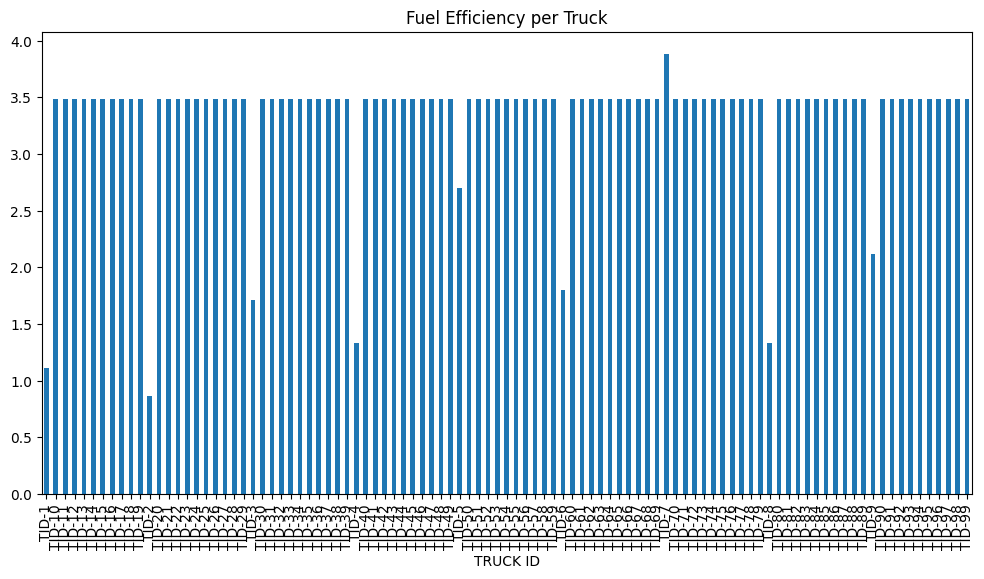

In [8]:
import matplotlib.pyplot as plt
truck_efficiency.plot(kind='bar', figsize=(12,6))
plt.title("Fuel Efficiency per Truck")
plt.show()

In [9]:
df['Performance'] = df['Fuel_Efficiency'].apply(
   lambda x: 'Excellent' if x >= 1.8 else 'Needs Improvement'
)
df.head()

,NO,TRUCK ID,DRIVER NAME,DATE,PERVIOUS ODO,CURRENT ODO,DISTANANCE,LITERS,K/L,TARGET CONS,Fuel_Efficiency,Performance
0,1,TID-1,NAME1,1/1/2026,1000,2000,1000,900,1.111111,1.8,1.111111,Needs Improvement
1,2,TID-2,NAME2,1/1/2026,1200,1890,690,800,0.862500,1.8,0.862500,Needs Improvement
2,3,TID-3,NAME3,1/1/2026,800,2000,1200,700,1.714286,1.8,1.714286,Needs Improvement
3,4,TID-4,NAME4,1/1/2026,1300,2500,1200,900,1.333333,1.8,1.333333,Needs Improvement
4,5,TID-5,NAME5,1/1/2026,1300,2500,1200,444,2.702703,1.8,2.702703,Excellent


In [10]:
df['Performance'].value_counts()

Performance
Excellent            93
Needs Improvement     6
Name: count, dtype: int64

In [11]:
truck_performance = df.groupby('TRUCK ID')['Fuel_Efficiency'].mean()
truck_performance.sort_values()

TRUCK ID
TID-2     0.862500
TID-1     1.111111
TID-4     1.333333
TID-8     1.333333
TID-3     1.714286
            ...   
TID-96    3.488372
TID-97    3.488372
TID-99    3.488372
TID-98    3.488372
TID-7     3.883495
Name: Fuel_Efficiency, Length: 99, dtype: float64

In [12]:
truck_performance.sort_values().head(10)

TRUCK ID
TID-2     0.862500
TID-1     1.111111
TID-4     1.333333
TID-8     1.333333
TID-3     1.714286
TID-6     1.799100
TID-9     2.116402
TID-5     2.702703
TID-16    3.488372
TID-17    3.488372
Name: Fuel_Efficiency, dtype: float64

In [13]:
truck_performance.sort_values(ascending=False).head(10)
 

TRUCK ID
TID-7     3.883495
TID-11    3.488372
TID-10    3.488372
TID-38    3.488372
TID-13    3.488372
TID-14    3.488372
TID-15    3.488372
TID-16    3.488372
TID-17    3.488372
TID-18    3.488372
Name: Fuel_Efficiency, dtype: float64

In [14]:
df['Fuel_Efficiency'].mean()
 

np.float64(3.3415126492794696)

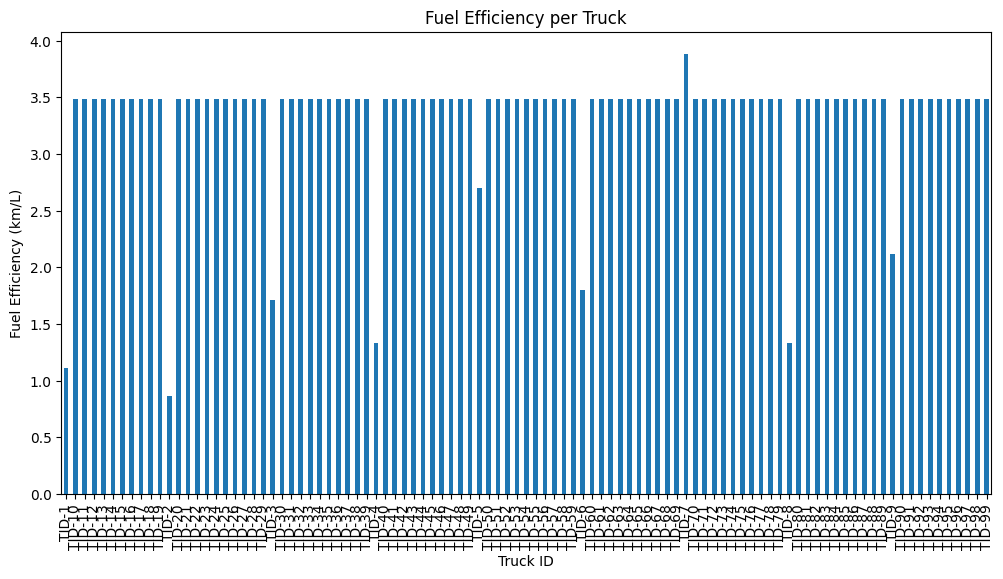

In [15]:
import matplotlib.pyplot as plt
truck_performance.plot(kind='bar', figsize=(12,6))
plt.title('Fuel Efficiency per Truck')
plt.xlabel('Truck ID')
plt.ylabel('Fuel Efficiency (km/L)')
plt.show()

In [16]:
driver_efficiency = df.groupby('DRIVER NAME')['Fuel_Efficiency'].mean()

driver_efficiency.sort_values()
 

DRIVER NAME
NAME2     0.862500
NAME1     1.111111
NAME4     1.333333
NAME8     1.333333
NAME3     1.714286
            ...   
NAME96    3.488372
NAME97    3.488372
NAME99    3.488372
NAME98    3.488372
NAME7     3.883495
Name: Fuel_Efficiency, Length: 99, dtype: float64

In [17]:
driver_efficiency.sort_values().head(10)
 

DRIVER NAME
NAME2     0.862500
NAME1     1.111111
NAME4     1.333333
NAME8     1.333333
NAME3     1.714286
NAME6     1.799100
NAME9     2.116402
NAME5     2.702703
NAME16    3.488372
NAME17    3.488372
Name: Fuel_Efficiency, dtype: float64

In [18]:
driver_efficiency.sort_values(ascending=False).head(10)

DRIVER NAME
NAME7     3.883495
NAME11    3.488372
NAME10    3.488372
NAME38    3.488372
NAME13    3.488372
NAME14    3.488372
NAME15    3.488372
NAME16    3.488372
NAME17    3.488372
NAME18    3.488372
Name: Fuel_Efficiency, dtype: float64

In [19]:
driver_performance = df.groupby('DRIVER NAME')['Fuel_Efficiency'].mean().reset_index()

driver_performance['Performance'] = driver_performance['Fuel_Efficiency'].apply(

    lambda x: 'Excellent' if x >= 1.8 else 'Needs Improvement'

)

driver_performance.sort_values('Fuel_Efficiency')
 

,DRIVER NAME,Fuel_Efficiency,Performance
11,NAME2,0.862500,Needs Improvement
0,NAME1,1.111111,Needs Improvement
33,NAME4,1.333333,Needs Improvement
77,NAME8,1.333333,Needs Improvement
22,NAME3,1.714286,Needs Improvement
...,...,...,...
95,NAME96,3.488372,Excellent
96,NAME97,3.488372,Excellent
98,NAME99,3.488372,Excellent
97,NAME98,3.488372,Excellent


In [20]:
driver_performance['Performance'].value_counts()
 

Performance
Excellent            93
Needs Improvement     6
Name: count, dtype: int64

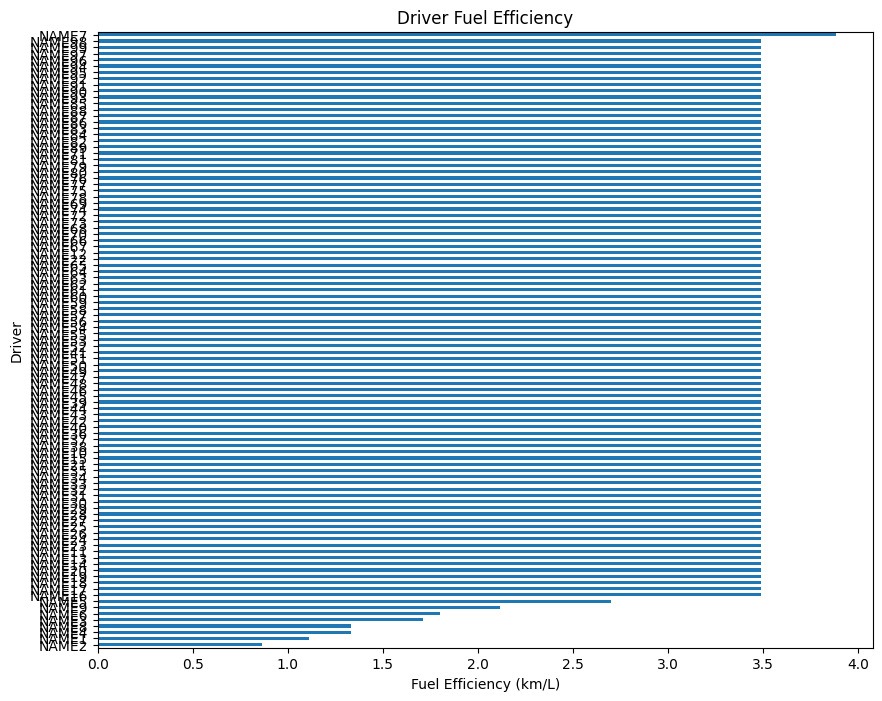

In [21]:
## Driver Performance Analysis

#Driver performance analysis shows significant variation in fuel efficiency.

#Some drivers consistently achieve fuel efficiency above the benchmark of 1.8 km/L, 

#while others operate below the expected level, indicating potential driving behavior issues.
 
import matplotlib.pyplot as plt
driver_efficiency.sort_values().plot(kind='barh', figsize=(10,8))
plt.title('Driver Fuel Efficiency')
plt.xlabel('Fuel Efficiency (km/L)')
plt.ylabel('Driver')
plt.show()

In [22]:
df['DATE'] = pd.to_datetime(df['DATE'])
df['Month'] = df['DATE'].dt.to_period('M')

In [23]:
monthly_efficiency = df.groupby('Month')['Fuel_Efficiency'].mean()
monthly_efficiency

Month
2026-01    3.341513
Freq: M, Name: Fuel_Efficiency, dtype: float64

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


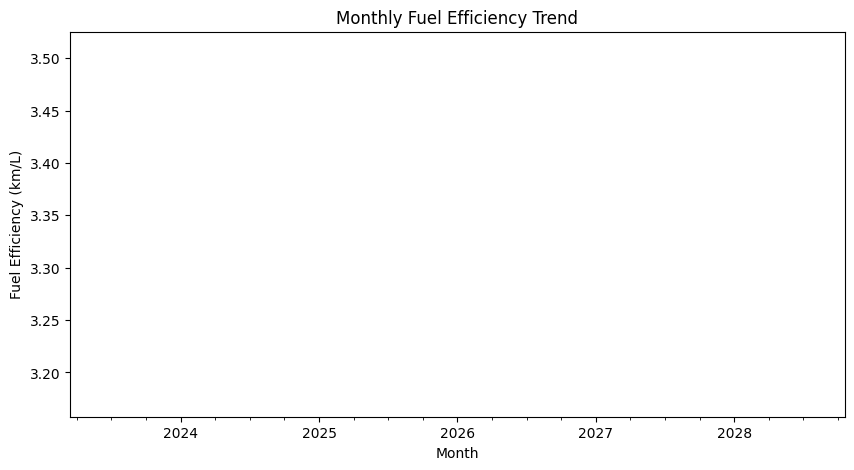

In [24]:
import matplotlib.pyplot as plt
monthly_efficiency.plot(figsize=(10,5))
plt.title('Monthly Fuel Efficiency Trend')
plt.xlabel('Month')
plt.ylabel('Fuel Efficiency (km/L)')
plt.show()

In [25]:
mean_eff = df['Fuel_Efficiency'].mean()
std_eff = df['Fuel_Efficiency'].std()
mean_eff, std_eff

(np.float64(3.3415126492794696), 0.5379143169133833)

In [26]:
threshold = mean_eff - 2 * std_eff
anomalies = df[df['Fuel_Efficiency'] < threshold]
anomalies

,NO,TRUCK ID,DRIVER NAME,DATE,PERVIOUS ODO,CURRENT ODO,DISTANANCE,LITERS,K/L,TARGET CONS,Fuel_Efficiency,Performance,Month
0,1,TID-1,NAME1,2026-01-01,1000,2000,1000,900,1.111111,1.8,1.111111,Needs Improvement,2026-01
1,2,TID-2,NAME2,2026-01-01,1200,1890,690,800,0.862500,1.8,0.862500,Needs Improvement,2026-01
2,3,TID-3,NAME3,2026-01-01,800,2000,1200,700,1.714286,1.8,1.714286,Needs Improvement,2026-01
3,4,TID-4,NAME4,2026-01-01,1300,2500,1200,900,1.333333,1.8,1.333333,Needs Improvement,2026-01
5,6,TID-6,NAME6,2026-01-01,1300,2500,1200,667,1.799100,1.8,1.799100,Needs Improvement,2026-01
7,8,TID-8,NAME8,2026-01-01,1300,2500,1200,900,1.333333,1.8,1.333333,Needs Improvement,2026-01
8,9,TID-9,NAME9,2026-01-01,1300,2500,1200,567,2.116402,1.8,2.116402,Excellent,2026-01


In [27]:
len(anomalies)

7

In [28]:
anomalies[['TRUCK ID','DRIVER NAME','Fuel_Efficiency','DATE']] 

,TRUCK ID,DRIVER NAME,Fuel_Efficiency,DATE
0,TID-1,NAME1,1.111111,2026-01-01
1,TID-2,NAME2,0.862500,2026-01-01
2,TID-3,NAME3,1.714286,2026-01-01
3,TID-4,NAME4,1.333333,2026-01-01
5,TID-6,NAME6,1.799100,2026-01-01
7,TID-8,NAME8,1.333333,2026-01-01
8,TID-9,NAME9,2.116402,2026-01-01


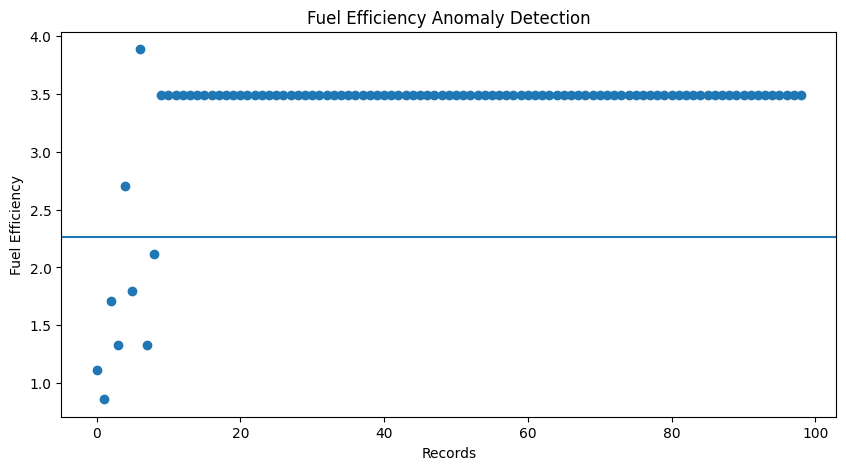

In [29]:
## Fuel Anomaly Detection
#Anomaly detection identified several records with unusually low fuel efficiency.
#These anomalies may indicate:
#- Mechanical issues
#- Driver behavior problems
#- Data entry errors
#- Fuel leakage or misuse
#Further investigation is recommended for affected trucks.

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.scatter(df.index, df['Fuel_Efficiency'])
plt.axhline(threshold)
plt.title("Fuel Efficiency Anomaly Detection")
plt.xlabel("Records")
plt.ylabel("Fuel Efficiency")
plt.show()